# JEPADepth &mdash; Model Internals & I-JEPA Masking



This notebook opens up **how JEPADepth works** rather than just running it:



- The **DINOv3 ViT encoder** and what its patch-token features look like.
- The **multi-scale FPN decoder** and its Monodepth2-style disparity outputs.
- The **I-JEPA context/target masking** strategy that drives the auxiliary self-supervised loss.
- The **accuracy vs. efficiency** trade-off against other monocular-depth methods.



**I-JEPA idea:** during training, the context encoder sees a large *context* block of the image and a small *predictor* network must predict the encoder representations of several held-out *target* blocks (produced by an EMA target encoder) &mdash; in **representation space**, not pixels. Combined with the photometric depth objective, this pushes the encoder toward more semantic, generalizable features.


## 1. Setup

In [ ]:
import os, sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(REPO_ROOT); sys.path.insert(0, REPO_ROOT)



import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.config.conf import Conf
from src.models.dinov3.dino import DINODepth
from src.utils import readlines, count_parameters, format_number

conf   = Conf().conf
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IM_H, IM_W = conf["im_sz"]
print("Device:", device, "| input:", f"{IM_W}x{IM_H}")

/home/ionut/miniconda3/envs/dino/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | input: 640x192


## 2. The DINOv3 encoder + FPN decoder



Build the JEPADepth model and inspect the two halves. The ViT operates on 16x16 patches, so a `192 x 640` image becomes a `12 x 40` patch grid.

In [ ]:
dc = conf["dino"]
model = DINODepth(dc["encoder_size"], dc["decoder_channels"], dc["scales"], dc["decoder_type"])
model.from_pretrained(dc["encoder_weights_path"], dc["decoder_weights_path"], device=device)
model.to(device).eval()

enc_params, _ = count_parameters(model.encoder)
dec_params, _ = count_parameters(model.decoder)

print(f"Encoder (DINOv3 ViT-{dc['encoder_size']}) : {format_number(enc_params)} params, embed_dim={model.encoder.embed_dim}")
print(f"Decoder ({dc['decoder_type'].upper()})              : {format_number(dec_params)} params")
print(f"Patch grid for {IM_W}x{IM_H} input : {IM_W//16} x {IM_H//16}")

Encoder (DINOv3 ViT-small) : 21.60M params, embed_dim=384
Decoder (FPN)              : 2.76M params
Patch grid for 640x192 input : 40 x 12


## 3. Multi-scale disparity outputs



The decoder returns disparity at 4 scales (Monodepth2 convention), used for the multi-scale photometric loss during training. Scale 0 is full resolution; each subsequent scale halves it.

In [ ]:
x = torch.rand(1, 3, IM_H, IM_W, device=device)
with torch.no_grad():
    outputs = model(x)

print("Multi-scale disparity outputs:")
for s in sorted(k[1] for k in outputs):
    print(f"  ('disp', {s}) : {tuple(outputs[('disp', s)].shape)}")

Multi-scale disparity outputs:
  ('disp', 0) : (1, 1, 192, 640)
  ('disp', 1) : (1, 1, 96, 320)
  ('disp', 2) : (1, 1, 48, 160)
  ('disp', 3) : (1, 1, 24, 80)


## 4. What does the encoder "see"? (patch-token PCA)



We take the ViT patch tokens, reduce their high-dimensional feature vectors to 3 channels via PCA, and render them as RGB. Coherent color regions mean the encoder groups semantically similar areas (road, cars, sky, vegetation) &mdash; the kind of structure the depth decoder exploits.

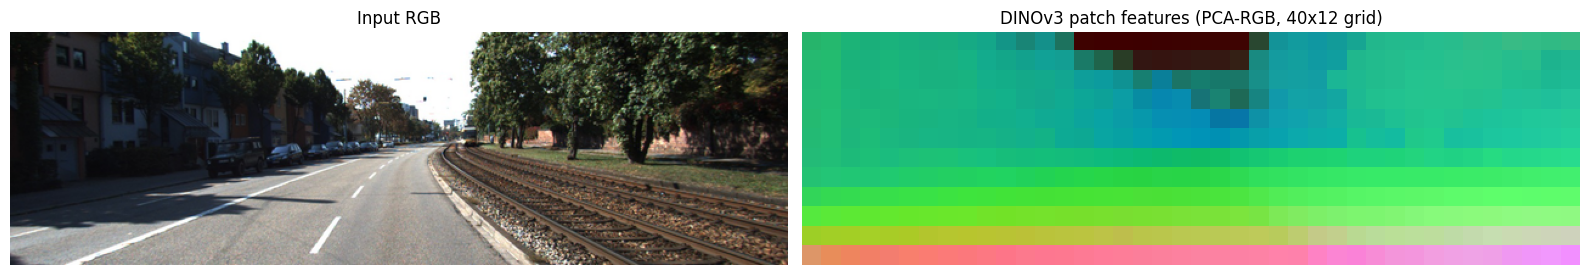

In [ ]:
import PIL.Image as pil
from torchvision import transforms

img_path = "src/inference/input_images/img1.jpg"
img = pil.open(img_path).convert("RGB").resize((IM_W, IM_H), pil.Resampling.LANCZOS)
t = transforms.ToTensor()(img).unsqueeze(0).to(device)

with torch.no_grad():
    feats = model.encoder.get_intermediate_layers(t, n=1, reshape=True)[0]   # [1, C, H/16, W/16]

C, gh, gw = feats.shape[1], feats.shape[2], feats.shape[3]
tokens = feats.squeeze(0).reshape(C, gh * gw).permute(1, 0).float()          # [N, C]


# PCA -> top 3 components -> normalize to [0,1] for RGB
tokens = tokens - tokens.mean(0, keepdim=True)
U, S, V = torch.pca_lowrank(tokens, q=3)
proj = tokens @ V[:, :3]
proj = (proj - proj.min(0).values) / (proj.max(0).values - proj.min(0).values + 1e-8)
pca_img = proj.reshape(gh, gw, 3).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].imshow(img);      axes[0].set_title("Input RGB")
axes[1].imshow(pca_img);  axes[1].set_title(f"DINOv3 patch features (PCA-RGB, {gw}x{gh} grid)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 5. I-JEPA context / target masking



Now the distinctive part of JEPADepth's training. The `MaskCollator` (from I-JEPA) samples, per image:

- one large **context** block (85&ndash;100% scale), and

- several small **target** blocks (15&ndash;20% scale, non-overlapping with context).



We visualize exactly the masks used at train time (parameters read from `conf['jepa']`), on real KITTI frames. Darkened = masked-out patches.

In [ ]:
from src.datasets.kitti_dataset import KITTIRAWDataset
from src.masks.mask_collator import MaskCollator



jc = conf["jepa"]
PATCH = jc["patch_size"]
NUM_SAMPLES = 4
NUM_TARGETS = jc["num_pred_masks"]

mask_collator = MaskCollator(
    input_size     = (IM_H, IM_W),
    patch_size     = PATCH,
    enc_mask_scale = jc["enc_mask_scale"],
    pred_mask_scale= jc["pred_mask_scale"],
    aspect_ratio   = jc["aspect_ratio"],
    nenc           = jc["num_enc_masks"],
    npred          = jc["num_pred_masks"],
    allow_overlap  = jc["allow_overlap"],
    min_keep       = jc["min_keep"],
)
train_files = readlines("data/kitti/kitti_splits/eigen_zhou/train_files.txt")
dataset = KITTIRAWDataset("data/kitti/kitti_data", train_files, IM_H, IM_W, [0, -1, 1], 4, is_train=True, img_ext=".jpg")
loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0, drop_last=True)

print(f"{len(dataset)} training frames | patch grid {IM_W//PATCH}x{IM_H//PATCH} = {(IM_W//PATCH)*(IM_H//PATCH)} patches")

39810 training frames | patch grid 40x12 = 480 patches


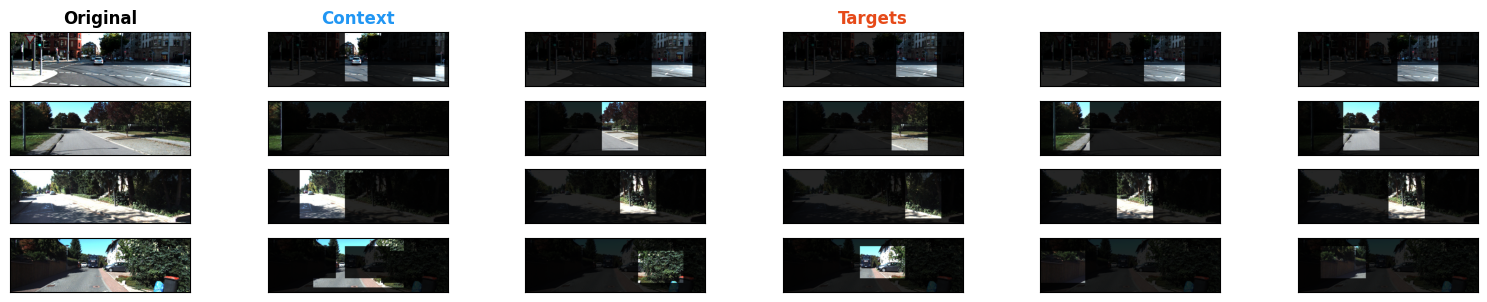

In [ ]:
def show_masked(ax, img, mask_indices, alpha=0.85):
    """Darken all patches NOT in mask_indices."""
    C, H, W = img.shape
    ph, pw = H // PATCH, W // PATCH
    keep = torch.zeros(ph * pw)
    keep[mask_indices] = 1.0
    keep = F.interpolate(keep.reshape(1, 1, ph, pw), size=(H, W), mode="nearest")[0]
    vis = img * keep + img * (1 - keep) * (1 - alpha)
    ax.imshow(vis.permute(1, 2, 0).clamp(0, 1).cpu().numpy())
    ax.set_xticks([]); ax.set_yticks([])


# Collect a few samples
samples = []
for inputs in loader:
    imgs = inputs["color_aug", 0, 0]                      # [1, 3, H, W]
    _, masks_enc, masks_tgt = mask_collator([imgs[0]])
    samples.append((imgs[0], masks_enc[0], [masks_tgt[k] for k in range(NUM_TARGETS)]))
    if len(samples) >= NUM_SAMPLES:
        break


n_cols = 2 + NUM_TARGETS
fig, axes = plt.subplots(NUM_SAMPLES, n_cols, figsize=(2.6 * n_cols, 2.6 * NUM_SAMPLES * IM_H / IM_W))
for r, (img, enc_mask, tgt_masks) in enumerate(samples):
    axes[r, 0].imshow(img.permute(1, 2, 0).clamp(0, 1).cpu().numpy()); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    show_masked(axes[r, 1], img, enc_mask)
    for k, tm in enumerate(tgt_masks):
        show_masked(axes[r, 2 + k], img, tm)
axes[0, 0].set_title("Original", fontweight="bold")
axes[0, 1].set_title("Context", fontweight="bold", color="#2196F3")
axes[0, 2 + (NUM_TARGETS - 1) // 2].set_title("Targets", fontweight="bold", color="#E64A19")
plt.tight_layout(); plt.show()

## 6. Accuracy vs. efficiency trade-off



JEPADepth's headline result: competitive KITTI AbsRel at a modest parameter budget. Lower-left is better (fewer params, lower error). Numbers mirror `src/analysis/params_performance_comparison.py`.

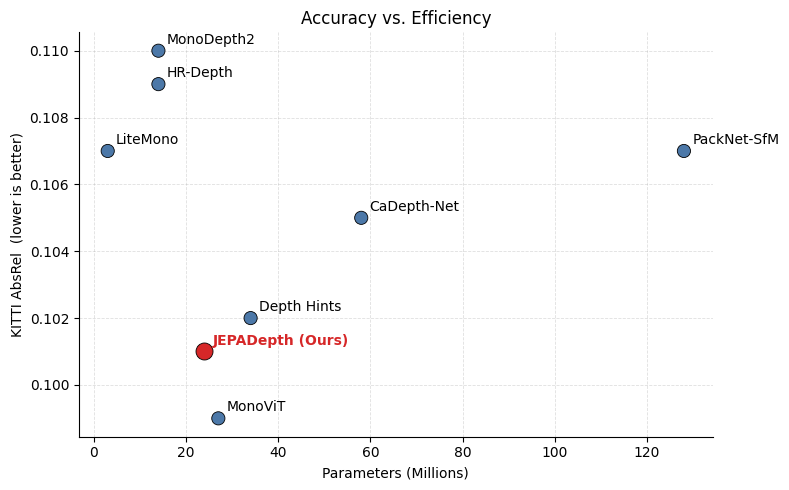

In [ ]:
methods = ["MonoDepth2", "CaDepth-Net", "PackNet-SfM", "HR-Depth", "LiteMono", "Depth Hints", "MonoViT", "JEPADepth (Ours)"]
params_m = np.array([14, 58, 128, 14, 3, 34, 27, 24])
absrel   = np.array([0.110, 0.105, 0.107, 0.109, 0.107, 0.102, 0.099, 0.101])


fig, ax = plt.subplots(figsize=(8, 5))
ours = methods.index("JEPADepth (Ours)")
colors = ["#4C78A8"] * len(methods); colors[ours] = "#D62728"
sizes  = [90] * len(methods);        sizes[ours]  = 150
ax.scatter(params_m, absrel, c=colors, s=sizes, edgecolor="black", linewidth=0.6, zorder=3)
for x, y, name in zip(params_m, absrel, methods):
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, 5), fontweight="bold" if "Ours" in name else "normal", color="#D62728" if "Ours" in name else "black", fontsize=10)
ax.set_xlabel("Parameters (Millions)"); ax.set_ylabel("KITTI AbsRel  (lower is better)")
ax.set_title("Accuracy vs. Efficiency"); ax.grid(True, ls="--", lw=0.6, alpha=0.4)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

---

### Related code



- **`src/masks/mask_collator.py`** &mdash; the I-JEPA mask sampler shown above.

- **`src/models/dinov3/`** &mdash; the DINOv3 encoder and `fpn_decoder.py` / DPT decoder.

- **`src/models/ijepa/`** &mdash; ViT predictor used for the JEPA loss.

- **`src/train/trainer.py`** &mdash; full training loop (`use_jepa_training: True` enables the JEPA objective).

- **`src/analysis/`** &mdash; standalone scripts for the figures reproduced here.